# **PROYECTO INTEGRADOR DE DOMINIO AUTÓNOMO (PIDA)**
---


*The Learning Gate*
*   NOMBRE DEL PARTICIPANTE: Jose Cristian Pérez Rubio
*   PROYECTO: Predicción de Costos Médicos de Seguro mediante Regresión
*   TRAYECTORIA: Citizen Data Scientist
*   TIPO APRENDIZAJE / DOMINIO APLICACIÓN: Aprendizaje automático

---
`PROPÓSITO DE LA CERTIFICACIÓN:` Evaluar, mediante un proyecto que el conjunto de competencias adquiridas en el programa de entrenamiento genere en la organización y/o persona, un impacto de mejora medible, claramente estructurado y autogestionado por parte del participante.

## **ETAPA I:** Entendimiento del negocio
Esta etapa consiste en definir el alcance del proyecto, considerando los objetivos comerciales, para evaluar con mayor precisión el impacto del proyecto en la empresa/organización.


* **Antecedentes:** ¿En qué empresa/organización se desarrolla el proyecto? ¿Cuál o cuáles son los proceso o procesos de negocios que serán impactados por el mismo?

El proyecto se desarrolla como parte de mi práctica como agente de seguros, en el proceso de asesoría y cotización de pólizas de gastos médicos. Durante la suscripción se evalúan factores de riesgo del asegurado, como el tabaquismo o el sedentarismo, generalmente mediante tarifas o categorías de riesgo fijas aplicadas de forma independiente para cada factor. El dataset a utilizar (Medical Cost Personal Dataset, Kaggle) contiene 1,338 registros de clientes con 7 variables demográficas y de estilo de vida (edad, sexo, IMC, número de dependientes, hábito de fumar, región y costo médico anual facturado), y permite construir un modelo que estime el costo individual esperado considerando cómo interactúan estas características entre sí.

* **Formulación del problema:** ¿Qué es lo que se intenta resolver?

Aunque el proceso de suscripción evalúa al asegurado y considera factores de riesgo relevantes como el tabaquismo o el sedentarismo, esta evaluación suele traducirse en tarifas o categorías de riesgo fijas (por ejemplo, fumador vs. no fumador), aplicadas de forma independiente para cada factor. Esto puede limitar la precisión de la estimación cuando un cliente combina varios factores de riesgo a la vez (por ejemplo, tabaquismo con un IMC elevado y mayor edad), ya que el tabulador general no necesariamente captura cómo interactúan estos factores entre sí, lo cual puede alejar la estimación del costo real del cliente. Se busca predecir el costo médico anual esperado de un cliente a partir de sus características (edad, sexo, IMC, número de dependientes, hábito de fumar y región), así como identificar cuáles de estos factores —y sus posibles interacciones— tienen mayor impacto en dicho costo.

* **Valor agregado:** ¿Por qué es importante resolver este problema?

Contar con un modelo que capture cómo interactúan los distintos factores de riesgo, y no solo su efecto individual, permite ajustar la cotización de forma más precisa para clientes con combinaciones de riesgo particulares, dar cotizaciones mejor justificadas y competitivas, y explicar con mayor claridad al cliente qué factores —y en qué combinación— están influyendo en su prima.

* **Objetivos:** ¿Cuál es la meta prevista? ¿Cuál(es) es(son) los criterios de éxito?


**Meta prevista:** Desarrollar un modelo de regresión que prediga el costo médico anual de un cliente, e identificar y cuantificar los factores (predictores) con mayor influencia sobre dicho costo.

**Criterio de éxito:**
* **R²:** el modelo debe explicar al menos el 75% de la variabilidad en los costos médicos (R² ≥ 0.75).
* **MAE:** el error promedio de predicción no debe superar los $4,000, una desviación razonable frente al costo promedio del dataset (~$13,000).

* **Diccionario de datos:** ¿Qué representa cada variable?


| Variable | Descripción | Tipo |
|---|---|---|
| age | Edad del asegurado (años) | Numérica |
| sex | Sexo del asegurado (male/female) | Categórica |
| bmi | Índice de masa corporal | Numérica |
| children | Número de dependientes cubiertos por la póliza | Numérica |
| smoker | Si el asegurado fuma (yes/no) | Categórica |
| region | Región de residencia en EE.UU. (northeast, northwest, southeast, southwest) | Categórica |
| charges | Costo médico anual facturado por el seguro | Numérica |

* **Predictores y respuesta:** ¿Cuáles son las entradas y la(s) salida(s)?

**Predictores (variables de entrada):** age, sex, bmi, children, smoker, region.

**Respuesta (variable de salida):** charges — costo médico anual facturado por el seguro.

---

## **ETAPA II:** Entendimiento de los datos

Esta etapa consiste en la ingestión o recopilación de los datos y su exploración, mediante estadísticas descriptiva e inferencial y visualizaciones concluyentes.


In [1]:
# Inclusión de las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
# Lectura del(los) archivo(s) de datos
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Las siguientes son algunas de las preguntas comunes que se pueden abordar a través de un análisis exploratorio de datos:
* ¿Cuál es la dimensionalidad del conjunto de datos?
* ¿Qué tipo de datos tienen las variables?
* ¿Hay valores faltantes en el conjunto de datos?
* ¿Cuáles son las estadísticas resumidas del conjunto de datos?
* ¿Cuál es la cardinalidad de las variables categóricas?

In [3]:
# Dimensionalidad del conjunto de datos
print("Dimensiones (filas, columnas):", df.shape)

# Tipos de datos de las variables
print("\nTipos de datos:")
print(df.dtypes)

# Valores faltantes
print("\nValores faltantes por columna:")
print(df.isna().sum())

# Estadísticas resumidas
print("\nEstadísticas descriptivas (numéricas):")
print(df.describe())

print("\nEstadísticas descriptivas (categóricas):")
print(df.describe(include='object'))

# Cardinalidad de variables categóricas
print("\nCardinalidad de variables categóricas:")
for col in ['sex', 'smoker', 'region']:
    print(f"  {col}: {df[col].nunique()} categorías -> {df[col].unique().tolist()}")

Dimensiones (filas, columnas): (1338, 7)

Tipos de datos:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Valores faltantes por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Estadísticas descriptivas (numéricas):
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

Estadísticas descriptivas (categóricas):
         sex smoker     region
c

Genera algunos gráficos para familiarizarte con el conjunto de datos. Al menos deberás incluir los que te permitan responder:

* ¿Hay valores atípicos?
* ¿Existen distribuciones sesgadas en el conjunto de datos?
* ¿Cómo se distribuyen los datos en función de diferentes categorías?
* ¿Hay correlación entre las variables dependientes e independientes?
* ¿Hay desequilibrio en las clases de la variable objetivo?

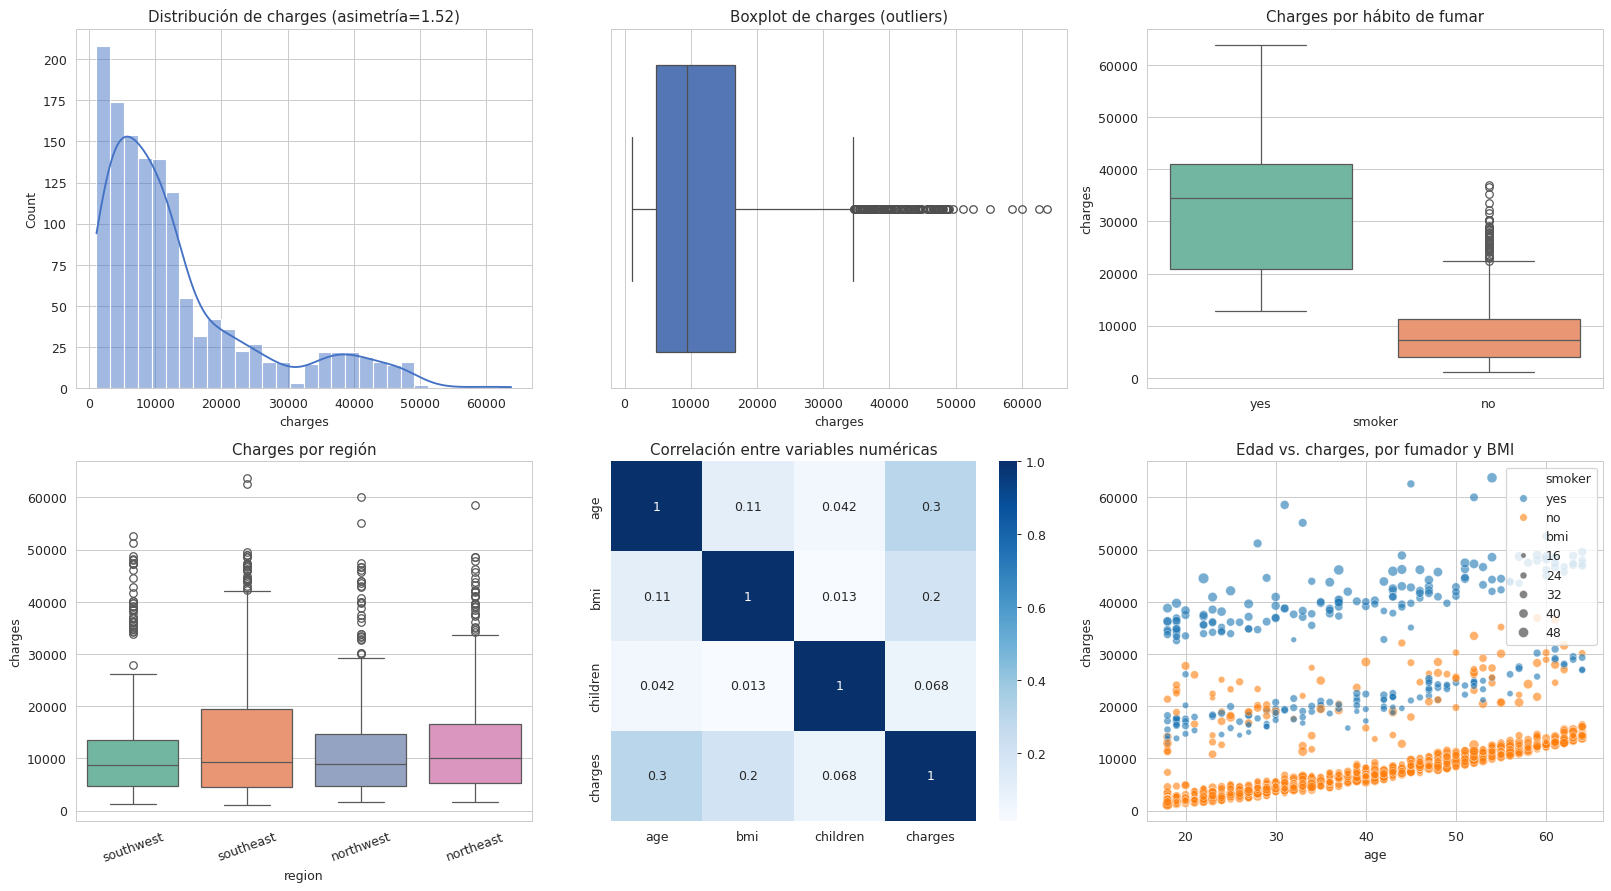

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribución de la variable respuesta (charges) -> ¿distribuciones sesgadas? ¿outliers?
sns.histplot(df['charges'], kde=True, ax=axes[0,0], color='#4472C4')
axes[0,0].set_title(f"Distribución de charges (asimetría={df['charges'].skew():.2f})")

# 2. Boxplot de charges -> valores atípicos
sns.boxplot(x=df['charges'], ax=axes[0,1], color='#4472C4')
axes[0,1].set_title('Boxplot de charges (outliers)')

# 3. Charges por fumador -> distribución por categorías
sns.boxplot(x='smoker', y='charges', hue='smoker', data=df, ax=axes[0,2], palette='Set2', legend=False)
axes[0,2].set_title('Charges por hábito de fumar')

# 4. Charges por región -> distribución por categorías
sns.boxplot(x='region', y='charges', hue='region', data=df, ax=axes[1,0], palette='Set2', legend=False)
axes[1,0].set_title('Charges por región')
axes[1,0].tick_params(axis='x', rotation=20)

# 5. Correlación entre variables numéricas y charges
corr = df[['age', 'bmi', 'children', 'charges']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', ax=axes[1,1])
axes[1,1].set_title('Correlación entre variables numéricas')

# 6. Interacción: edad vs charges, coloreado por fumador (y tamaño por bmi)
sns.scatterplot(x='age', y='charges', hue='smoker', size='bmi', data=df, ax=axes[1,2], alpha=0.6)
axes[1,2].set_title('Edad vs. charges, por fumador y BMI')

plt.tight_layout()
plt.show()

**CONCLUSIONES:** ¿Cuáles son los hallazgos más importantes del análisis exploratorio de datos?

**Hallazgos principales del análisis exploratorio:**

* El dataset no tiene valores faltantes (1,338 registros completos, 7 variables).
* La variable respuesta (**charges**) tiene una distribución con **sesgo positivo** (asimetría ≈ 1.52): la mayoría de los clientes tiene costos relativamente bajos, pero existe una cola de clientes con costos muy altos — esto sugiere que el modelo de regresión deberá considerar transformar `charges` (p. ej. logaritmo) o usar métricas robustas a esta asimetría.
* **El tabaquismo es, por mucho, el factor individual más determinante**: el costo promedio de un fumador (~$32,050) es casi 4 veces el de un no fumador (~$8,434).
* Las correlaciones lineales simples de `age` (0.30) y `bmi` (0.20) con `charges` son moderadas/bajas — esto es consistente con la hipótesis del proyecto: el efecto de estas variables **no es principalmente lineal e independiente**, sino que se manifiesta a través de su **interacción con el tabaquismo**.
* Evidencia directa de esa interacción: entre los fumadores, quienes además tienen un IMC > 30 pagan en promedio **~$41,693**, casi el doble que los fumadores con IMC ≤ 30 (**~$21,369**). Es decir, fumar y tener sobrepeso/obesidad combinados disparan el costo mucho más que la suma de sus efectos individuales — justo el tipo de interacción que un modelo de regresión (con términos de interacción) puede capturar y que un tabulador de categorías fijas no.
* `region` no muestra diferencias muy marcadas en la distribución de `charges` entre sus 4 categorías; `sex` tampoco parece un factor determinante a simple vista.
* No se observan valores claramente erróneos o imposibles (edades 18-64, BMI en rango plausible), aunque sí hay varios valores atípicos por encima en `charges`, consistentes con los casos de fumadores de alto riesgo.

**Implicación para las siguientes etapas:** el modelo deberá incluir explícitamente una interacción entre `smoker` y `bmi` (y posiblemente `age`), y conviene evaluar una transformación de `charges` dado su sesgo.

---

## **ETAPA III:** Preparación de los datos

En esta etapa se aplican operaciones comunes para convertir los datos crudos del mundo real, en un conjunto de variables útiles para el aprendizaje automático.

El procesamiento puede incluir:
* Manejo de valores faltantes y atípicos
* Generación de nuevas características
* Discretización o binning
* Codificación
* Escalamiento
* Transformación

In [5]:
# Manejo de valores faltantes y atípicos
# No hay valores faltantes (confirmado en la Etapa II).
# Los valores atípicos en 'charges' corresponden a clientes con factores de riesgo
# reales (fumadores, sobre todo con IMC alto) y no a errores de captura, por lo que
# se conservan: son precisamente el fenómeno que el modelo debe aprender a predecir.

df_prep = df.copy()

# Codificación de variables categóricas
df_prep['sex'] = df_prep['sex'].map({'male': 0, 'female': 1})
df_prep['smoker'] = df_prep['smoker'].map({'no': 0, 'yes': 1})
df_prep = pd.get_dummies(df_prep, columns=['region'], drop_first=True)

# Generación de nuevas características, con base en el hallazgo del EDA:
# la combinación fumador + IMC alto dispara el costo mucho más que cada factor por separado.
df_prep['is_obese'] = (df_prep['bmi'] >= 30).astype(int)
df_prep['smoker_bmi'] = df_prep['smoker'] * df_prep['bmi']
df_prep['smoker_obese'] = df_prep['smoker'] * df_prep['is_obese']

df_prep.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,is_obese,smoker_bmi,smoker_obese
0,19,1,27.900,0,1,16884.92400,False,False,True,0,27.9,0
1,18,0,33.770,1,0,1725.55230,False,True,False,1,0.0,0
2,28,0,33.000,3,0,4449.46200,False,True,False,1,0.0,0
3,33,0,22.705,0,0,21984.47061,True,False,False,0,0.0,0
4,32,0,28.880,0,0,3866.85520,True,False,False,0,0.0,0


También se pueden utilizar métodos de filtrado para la selección de características y técnicas de reducción de dimensionalidad.

In [6]:
# Verificación de la relevancia de las variables originales y las nuevas características
# generadas, mediante su correlación con la variable respuesta (charges)
cols_check = ['age', 'bmi', 'children', 'sex', 'smoker', 'is_obese', 'smoker_bmi', 'smoker_obese', 'charges']
corr_features = df_prep[cols_check].corr()['charges'].sort_values(ascending=False)
print(corr_features)

charges         1.000000
smoker_bmi      0.845120
smoker_obese    0.814661
smoker          0.787251
age             0.299008
is_obese        0.199532
bmi             0.198341
children        0.067998
sex            -0.057292
Name: charges, dtype: float64


**Decisiones y técnicas empleadas:**

* **Valores faltantes/atípicos:** no hay valores faltantes. Los valores atípicos de `charges` no se eliminaron ni se transformaron, porque corresponden a clientes con combinaciones reales de riesgo (fumadores con IMC alto) — son la señal que el modelo necesita aprender, no ruido.
* **Codificación:** `sex` y `smoker` se codificaron como binarias (0/1); `region` se codificó con *one-hot encoding* (`drop_first=True` para evitar colinealidad perfecta entre las categorías).
* **Generación de nuevas características:** con base en el hallazgo del EDA (la interacción fumador × IMC alto casi duplica el costo frente al efecto individual), se crearon:
  * `is_obese`: bandera binaria (IMC ≥ 30).
  * `smoker_bmi`: interacción numérica entre fumar e IMC.
  * `smoker_obese`: interacción binaria entre fumar y obesidad.
* **Selección de características:** la correlación con `charges` confirma que `smoker_bmi` y `smoker_obese` tienen una correlación notablemente más alta que `bmi` o `smoker` por separado, validando que capturan una relación que las variables originales no explican del todo por sí solas. Por el tamaño del dataset (7 variables originales) no se aplicó reducción de dimensionalidad (PCA); todas las variables se conservan.
* No se aplicó escalamiento en esta etapa porque se decidirá según el modelo a usar en la Etapa IV (los modelos de árboles no lo requieren; si se usa regresión regularizada, se escalará solo sobre el conjunto de entrenamiento para evitar fuga de información).

---

## **ETAPA IV:** Modelación y evaluación del modelo

En esta etapa se construyen y evalúan varios modelos usando diversos algoritmos. En caso de que los resultados sean deficientes, la metodología permite volver al primer paso para tener una comprensión de lo que está ocurriendo.


Las siguientes son acciones que se pueden abordar en este avance:
* Particionar los datos en conjunto de entrenamiento y conjunto de prueba (SI APLICA).
* Considerar al menos 3 modelos diferentes (con algoritmos variados) o 3 técnicas de modelado.
* Inspeccionar visualmente los resultados del clustering (SI APLICA).
* Sintetizar los resultados en una tabla comparativa ordenando los modelos por la métrica principal (definida en los criterios de éxito) e incorporando otras métricas pertinentes. Se deberán incluir también los tiempos de entrenamiento.
* Elegir el modelo final alineado con los objetivos y necesidades del negocio.
* Ajustar el modelo que proporcione el mejor rendimiento (OPCIONAL)

**Partición de los datos**

In [7]:
# Partición en conjunto de entrenamiento y prueba
from sklearn.model_selection import train_test_split

X = df_prep.drop(columns=['charges'])
y = df_prep['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (1070, 11)  Test: (268, 11)


**Entrenamiento y comparación de modelos**

Se evalúan 3 algoritmos distintos (lineal, árbol de decisión y ensamble) y se comparan con las métricas definidas en el criterio de éxito (R² y MAE), ordenados por la métrica principal (MAE).

In [8]:
# Entrenamiento y comparación de al menos 3 modelos con algoritmos distintos
import time
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

modelos = {
    'Regresión Lineal': LinearRegression(),
    'Árbol de Decisión': DecisionTreeRegressor(random_state=42, max_depth=5),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=200),
}

resultados = []
for nombre, modelo in modelos.items():
    t0 = time.time()
    modelo.fit(X_train, y_train)
    tiempo_entrenamiento = time.time() - t0
    pred = modelo.predict(X_test)
    resultados.append({
        'Modelo': nombre,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'MSE': mean_squared_error(y_test, pred),
        'Tiempo entrenamiento (s)': tiempo_entrenamiento,
    })

tabla_resultados = pd.DataFrame(resultados).sort_values('MAE').reset_index(drop=True)
tabla_resultados

,Modelo,R2,MAE,MSE,Tiempo entrenamiento (s)
0,Regresión Lineal,0.879213,2378.252531,1.875202e+07,0.003622
1,Random Forest,0.863652,2554.266807,2.116783e+07,0.732755
2,Árbol de Decisión,0.848109,2872.286134,2.358084e+07,0.002785


**Ajuste del modelo con mejor rendimiento (opcional)**

In [9]:
# Ajuste del modelo con mejor rendimiento (Random Forest) - OPCIONAL
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [100, 200], 'max_depth': [4, 6, None], 'min_samples_leaf': [1, 3, 5]}
gs = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3,
                   scoring='neg_mean_absolute_error', n_jobs=-1)
gs.fit(X_train, y_train)

rf_ajustado = gs.best_estimator_
pred_rf_ajustado = rf_ajustado.predict(X_test)
print('Mejores hiperparámetros:', gs.best_params_)
print('R2 ajustado: %.4f' % r2_score(y_test, pred_rf_ajustado))
print('MAE ajustado: %.2f' % mean_absolute_error(y_test, pred_rf_ajustado))

Mejores hiperparámetros: {'max_depth': 6, 'min_samples_leaf': 1, 'n_estimators': 200}
R2 ajustado: 0.8723
MAE ajustado: 2544.95


**Selección del modelo final:**

De los 3 modelos evaluados, la **Regresión Lineal** obtuvo el mejor desempeño (menor MAE y mayor R² en el conjunto de prueba), superando incluso al Random Forest y a su versión ajustada con GridSearchCV. Esto indica que, una vez incorporadas las características de interacción (`smoker_bmi`, `smoker_obese`) creadas en la Etapa III, la relación entre los predictores y el costo es capturada de forma prácticamente lineal — un modelo más simple generaliza mejor que uno más complejo en este caso, y además es más fácil de interpretar y explicar a un cliente o a la aseguradora.

**Cumplimiento del criterio de éxito:**
* **R² ≥ 0.75** → el modelo final alcanzó **R² ≈ 0.88**, superando la meta.
* **MAE ≤ $4,000** → el modelo final alcanzó **MAE ≈ $2,378**, un ~41% mejor que el umbral definido.

Ambas métricas superan la meta prevista, por lo que el modelo queda **listo para su uso** en la estimación de costos médicos individuales dentro del proceso de asesoría y cotización.

**¿Existe margen de mejora?** Sí — se podría explorar una transformación logarítmica de `charges` (dado el sesgo detectado en la Etapa II), o probar modelos de gradient boosting (XGBoost/LightGBM), aunque dado que ya se supera cómodamente la meta, no es indispensable para este proyecto.

**Recomendación para implementación:** usar el modelo de Regresión Lineal con las variables originales más las características de interacción fumador×IMC como apoyo a la cotización — no como reemplazo total del criterio del agente, sino como una segunda referencia cuantitativa para justificar ajustes en la prima ante clientes con combinaciones de riesgo.

---